## Editing efficiency, ABE focused v1 and v2

In [74]:
import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

BASE = '/Users/kexindong/Documents/GitHub/B-ALL-in-vivo-base-editing/'

In [75]:
fp1 = 'crispresso/focused'
fp2 = 'crispresso/fsr'
ABE_BC_RAW = sorted(os.listdir(f'{fp1}/ABE_BC'))
ABE_EPO_RAW = sorted(os.listdir(f'{fp1}/ABE_EPO'))
ABE_BC_v2_RAW = sorted(os.listdir(f'{fp2}/ABE_BC'))
ABE_EPO_v2_RAW = sorted(os.listdir(f'{fp2}/ABE_EPO'))

#set filters for minimum number of sensor reads
min_sensor_reads = 50
name_dict = { 'spleen':'Spleen', 'bm':'Bone Marrow', 'd5':'D5', 'd15':'D15', 'lib':'Plasmid', 'input':'Input (D0)'}

In [76]:
FOCUSED = pd.read_csv(BASE + 'MBESv2_focused.csv')
ABE = FOCUSED[(FOCUSED['Editor']=='ABE') & (FOCUSED['classification']=='targeting guide')]

In [77]:
t = []
corr = []
name = []

# bm1/3/5, d15 rep1-3, d5, input, lib, spleen1/3
ABE_BC_RAW_USED = [ABE_BC_RAW[i] for i in [0,2,4, 5,6,7, 10,11,12, 13,15]]
list_samples = ['bm']*3+['d15']*3+['d5','input','lib']+['spleen']*2

for i in ABE_BC_RAW_USED:
    g = pd.read_csv(f'{fp1}/ABE_BC/{i}').rename(columns = {'Guide_ID':'gRNA_id'})
    g2 = pd.merge(g, ABE, on='gRNA_id')
    g2 = g2[g2['Reads_aligned_all_amplicons']>=min_sensor_reads]
    t.append(np.average(g2['target_base_edit_perc']))
    corr.append(np.average(g2['corr_perc']))

In [78]:
ABE_BC_RAW

['bm1_compact_unfiltered.csv',
 'bm2_compact_unfiltered.csv',
 'bm3_compact_unfiltered.csv',
 'bm4_compact_unfiltered.csv',
 'bm5_compact_unfiltered.csv',
 'd15-rep1_compact_unfiltered.csv',
 'd15-rep2_compact_unfiltered.csv',
 'd15-rep3_compact_unfiltered.csv',
 'd15-rep4_compact_unfiltered.csv',
 'd15-rep5_compact_unfiltered.csv',
 'd5_compact_unfiltered.csv',
 'input_compact_unfiltered.csv',
 'lib_compact_unfiltered.csv',
 'spleen1_compact_unfiltered.csv',
 'spleen2_compact_unfiltered.csv',
 'spleen3_compact_unfiltered.csv',
 'spleen4_compact_unfiltered.csv',
 'spleen5_compact_unfiltered.csv']

In [79]:
name = [name_dict[x] for x in list_samples]
ABE_BC_editing1 = pd.DataFrame(dict(zip(['Sample', 'Editing %',], [name, t,])))
ABE_BC_editing2 = pd.DataFrame(dict(zip(['Sample', 'Editing %'], [name, corr])))
ABE_BC_editing1['Edit Type'] = 'Target Editing (w/ Bystanders)'
ABE_BC_editing2['Edit Type'] = 'Pure Correct Editing'
ABE_BC_EDITING = pd.concat((ABE_BC_editing1, ABE_BC_editing2))

In [85]:
t = []
corr = []
name = []

# bm1-5, d15 1-3, input1/2/input, spleen1/2/4/5 (no spleen3)
ABE_BC_v2_RAW_USED = [ABE_BC_v2_RAW[i] for i in [0,1,2,3,4, 5,6,7, 8,9,10, 11,12,13,14]]
list_samples = ['bm']*5+['d15']*3+['input']*3+['spleen']*4

for i in ABE_BC_v2_RAW_USED:
    g = pd.read_csv(f'{fp2}/ABE_BC/{i}').rename(columns = {'Guide_ID':'gRNA_id'})
    g2 = pd.merge(g, ABE, on='gRNA_id')
    g2 = g2[g2['Reads_aligned_all_amplicons']>=min_sensor_reads]
    t.append(np.average(g2['target_base_edit_perc']))
    corr.append(np.average(g2['corr_perc']))

In [86]:
ABE_BC_v2_RAW

['bm1_compact_unfiltered.csv',
 'bm2_compact_unfiltered.csv',
 'bm3_compact_unfiltered.csv',
 'bm4_compact_unfiltered.csv',
 'bm5_compact_unfiltered.csv',
 'd15-rep1_compact_unfiltered.csv',
 'd15-rep2_compact_unfiltered.csv',
 'd15-rep3_compact_unfiltered.csv',
 'input1_compact_unfiltered.csv',
 'input2_compact_unfiltered.csv',
 'input_compact_unfiltered.csv',
 'spleen1_compact_unfiltered.csv',
 'spleen2_compact_unfiltered.csv',
 'spleen4_compact_unfiltered.csv',
 'spleen5_compact_unfiltered.csv']

In [87]:
ABE_BC_v2_RAW_USED

['bm1_compact_unfiltered.csv',
 'bm2_compact_unfiltered.csv',
 'bm3_compact_unfiltered.csv',
 'bm4_compact_unfiltered.csv',
 'bm5_compact_unfiltered.csv',
 'd15-rep1_compact_unfiltered.csv',
 'd15-rep2_compact_unfiltered.csv',
 'd15-rep3_compact_unfiltered.csv',
 'input1_compact_unfiltered.csv',
 'input2_compact_unfiltered.csv',
 'input_compact_unfiltered.csv',
 'spleen1_compact_unfiltered.csv',
 'spleen2_compact_unfiltered.csv',
 'spleen4_compact_unfiltered.csv',
 'spleen5_compact_unfiltered.csv']

In [88]:
ABE_BC_v2_RAW

['bm1_compact_unfiltered.csv',
 'bm2_compact_unfiltered.csv',
 'bm3_compact_unfiltered.csv',
 'bm4_compact_unfiltered.csv',
 'bm5_compact_unfiltered.csv',
 'd15-rep1_compact_unfiltered.csv',
 'd15-rep2_compact_unfiltered.csv',
 'd15-rep3_compact_unfiltered.csv',
 'input1_compact_unfiltered.csv',
 'input2_compact_unfiltered.csv',
 'input_compact_unfiltered.csv',
 'spleen1_compact_unfiltered.csv',
 'spleen2_compact_unfiltered.csv',
 'spleen4_compact_unfiltered.csv',
 'spleen5_compact_unfiltered.csv']

In [89]:
name = [name_dict[x] for x in list_samples]
ABE_BC_editing1 = pd.DataFrame(dict(zip(['Sample', 'Editing %',], [name, t,])))
ABE_BC_editing2 = pd.DataFrame(dict(zip(['Sample', 'Editing %'], [name, corr])))
ABE_BC_editing1['Edit Type'] = 'Target Editing (w/ Bystanders)'
ABE_BC_editing2['Edit Type'] = 'Pure Correct Editing'
ABE_BC_EDITING_V2 = pd.concat((ABE_BC_editing1, ABE_BC_editing2))

In [90]:
i = 'input_compact_unfiltered.csv'
g = pd.read_csv(f'{fp1}/ABE_EPO/{i}').rename(columns = {'Guide_ID':'gRNA_id'})
g2 = pd.merge(g, ABE, on='gRNA_id')

In [91]:
t = []
corr = []
name = []

for i in ABE_EPO_RAW:
    print(i)
    g = pd.read_csv(f'{fp1}/ABE_EPO/{i}').rename(columns = {'Guide_ID':'gRNA_id'})
    g2 = pd.merge(g, ABE, on='gRNA_id')
    g2 = g2[g2['Reads_aligned_all_amplicons']>=min_sensor_reads]
    t.append(np.average(g2['target_base_edit_perc']))
    corr.append(np.average(g2['corr_perc']))

list_samples = ['bm']*5+['d15']*5+['d5','input','lib']+['spleen']*5

name = [name_dict[x] for x in list_samples]
ABE_EPO_editing1 = pd.DataFrame(dict(zip(['Sample', 'Editing %',], [name, t,])))
ABE_EPO_editing2 = pd.DataFrame(dict(zip(['Sample', 'Editing %'], [name, corr])))
ABE_EPO_editing1['Edit Type'] = 'Target Editing (w/ Bystanders)'
ABE_EPO_editing2['Edit Type'] = 'Pure Correct Editing'
ABE_EPO_EDITING = pd.concat((ABE_EPO_editing1, ABE_EPO_editing2))

bm1_compact_unfiltered.csv
bm2_compact_unfiltered.csv
bm3_compact_unfiltered.csv
bm4_compact_unfiltered.csv
bm5_compact_unfiltered.csv
d15-rep1_compact_unfiltered.csv
d15-rep2_compact_unfiltered.csv
d15-rep3_compact_unfiltered.csv
d15-rep4_compact_unfiltered.csv
d15-rep5_compact_unfiltered.csv
d5_compact_unfiltered.csv
input_compact_unfiltered.csv
lib_compact_unfiltered.csv
spleen1_compact_unfiltered.csv
spleen2_compact_unfiltered.csv
spleen3_compact_unfiltered.csv
spleen4_compact_unfiltered.csv
spleen5_compact_unfiltered.csv


In [92]:
ABE_EPO_EDITING

,Sample,Editing %,Edit Type
0,Bone Marrow,84.267874,Target Editing (w/ Bystanders)
1,Bone Marrow,81.777630,Target Editing (w/ Bystanders)
2,Bone Marrow,79.392622,Target Editing (w/ Bystanders)
3,Bone Marrow,81.464935,Target Editing (w/ Bystanders)
4,Bone Marrow,85.275510,Target Editing (w/ Bystanders)
5,D15,82.987438,Target Editing (w/ Bystanders)
6,D15,83.632498,Target Editing (w/ Bystanders)
7,D15,84.709774,Target Editing (w/ Bystanders)
8,D15,82.858019,Target Editing (w/ Bystanders)
9,D15,81.773336,Target Editing (w/ Bystanders)


In [93]:
t = []
corr = []
name = []

for i in ABE_EPO_v2_RAW:
    g = pd.read_csv(f'{fp2}/ABE_EPO/{i}').rename(columns = {'Guide_ID':'gRNA_id'})
    g2 = pd.merge(g, ABE, on='gRNA_id')
    g2 = g2[g2['Reads_aligned_all_amplicons']>=min_sensor_reads]
    t.append(np.average(g2['target_base_edit_perc']))
    corr.append(np.average(g2['corr_perc']))
list_samples = ['bm']*5+['d15']*3+['input','lib','d5']+['spleen']*5

In [94]:
ABE_EPO_v2_RAW

['bm1_compact_unfiltered.csv',
 'bm2_compact_unfiltered.csv',
 'bm3_compact_unfiltered.csv',
 'bm4_compact_unfiltered.csv',
 'bm5_compact_unfiltered.csv',
 'd15-rep1_compact_unfiltered.csv',
 'd15-rep2_compact_unfiltered.csv',
 'd15-rep3_compact_unfiltered.csv',
 'input1_compact_unfiltered.csv',
 'input2_compact_unfiltered.csv',
 'input_compact_unfiltered.csv',
 'spleen1_compact_unfiltered.csv',
 'spleen2_compact_unfiltered.csv',
 'spleen3_compact_unfiltered.csv',
 'spleen4_compact_unfiltered.csv',
 'spleen5_compact_unfiltered.csv']

In [95]:

name = [name_dict[x] for x in list_samples]
ABE_EPO_editing1 = pd.DataFrame(dict(zip(['Sample', 'Editing %',], [name, t,])))
ABE_EPO_editing2 = pd.DataFrame(dict(zip(['Sample', 'Editing %'], [name, corr])))
ABE_EPO_editing1['Edit Type'] = 'Target Editing (w/ Bystanders)'
ABE_EPO_editing2['Edit Type'] = 'Pure Correct Editing'
ABE_EPO_EDITING_V2 = pd.concat((ABE_EPO_editing1, ABE_EPO_editing2))

In [96]:
ABE_EPO_EDITING_V2

,Sample,Editing %,Edit Type
0,Bone Marrow,76.696895,Target Editing (w/ Bystanders)
1,Bone Marrow,78.540210,Target Editing (w/ Bystanders)
2,Bone Marrow,78.132759,Target Editing (w/ Bystanders)
3,Bone Marrow,78.979566,Target Editing (w/ Bystanders)
4,Bone Marrow,78.222119,Target Editing (w/ Bystanders)
5,D15,79.454605,Target Editing (w/ Bystanders)
6,D15,80.133506,Target Editing (w/ Bystanders)
7,D15,79.083848,Target Editing (w/ Bystanders)
8,Input (D0),1.543210,Target Editing (w/ Bystanders)
9,Plasmid,1.534032,Target Editing (w/ Bystanders)


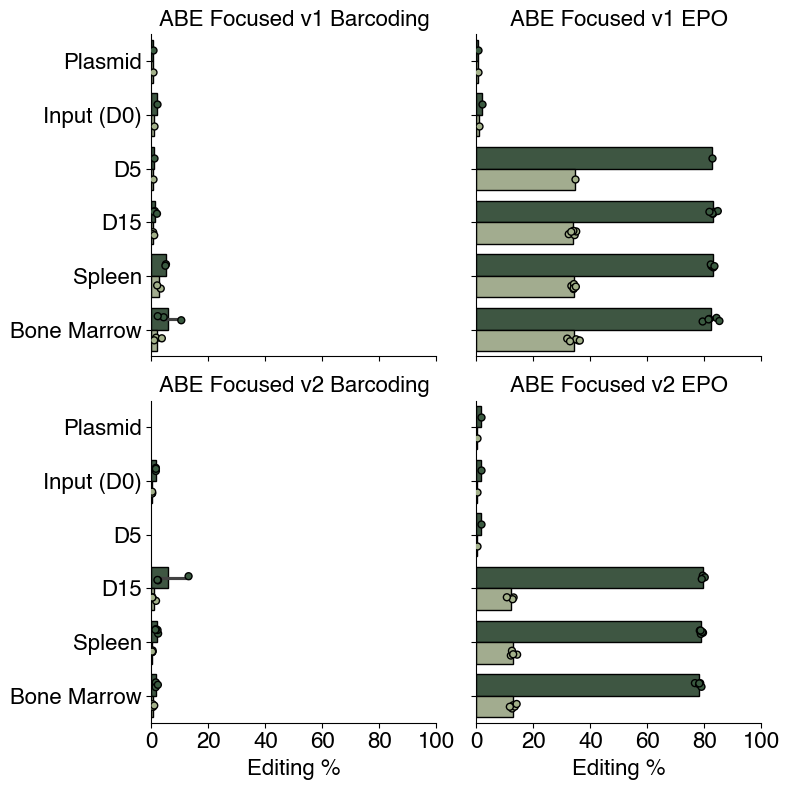

In [97]:
fig, ax = plt.subplots(2,2, figsize=(8,8), sharey=True, sharex=True)
order = ['Plasmid', 'Input (D0)', 'D5', 'D15', 'Spleen', 'Bone Marrow']

sns.barplot(data = ABE_BC_EDITING, y='Sample', x='Editing %', hue='Edit Type', ax=ax[0][0], edgecolor='black', linewidth=1, palette = ['#3a5a40', '#a3b18a'], order=order)
sns.barplot(data = ABE_EPO_EDITING, y='Sample', x='Editing %', hue='Edit Type', ax=ax[0][1], edgecolor='black', linewidth=1, palette = ['#3a5a40', '#a3b18a'],order=order)
sns.barplot(data = ABE_BC_EDITING_V2, y='Sample', x='Editing %', hue='Edit Type', ax=ax[1][0], edgecolor='black', linewidth=1, palette = ['#3a5a40', '#a3b18a'], order=order)
sns.barplot(data = ABE_EPO_EDITING_V2, y='Sample', x='Editing %', hue='Edit Type', ax=ax[1][1], edgecolor='black', linewidth=1, palette = ['#3a5a40', '#a3b18a'],order=order)

sns.stripplot(data = ABE_BC_EDITING, y='Sample', x='Editing %', hue='Edit Type', ax=ax[0][0], edgecolor='black', linewidth=1, palette = ['#3a5a40', '#a3b18a'], order=order, dodge=True, s=5)
sns.stripplot(data = ABE_EPO_EDITING, y='Sample', x='Editing %', hue='Edit Type', ax=ax[0][1], edgecolor='black', linewidth=1, palette = ['#3a5a40', '#a3b18a'],order=order, dodge=True, s=5)
sns.stripplot(data = ABE_BC_EDITING_V2, y='Sample', x='Editing %', hue='Edit Type', ax=ax[1][0], edgecolor='black', linewidth=1, palette = ['#3a5a40', '#a3b18a'], order=order, dodge=True, s=5)
sns.stripplot(data = ABE_EPO_EDITING_V2, y='Sample', x='Editing %', hue='Edit Type', ax=ax[1][1], edgecolor='black', linewidth=1, palette =['#3a5a40', '#a3b18a'],order=order, dodge=True, s=5)

ax[0][0].legend([],[], frameon=False)
ax[0][1].legend([],[], frameon=False)
ax[1][0].legend([],[], frameon=False)
ax[1][1].legend([],[], frameon=False)

ax[0][0].set_ylabel('')
ax[1][0].set_ylabel('')
ax[0][0].set_xticks([0,20,40,60,80,100])

ax[0][0].spines[['top', 'right']].set_visible(False)
ax[0][0].tick_params(axis='both', which='major', labelsize=16,)
ax[1][0].spines[['top', 'right']].set_visible(False)
ax[1][0].tick_params(axis='both', which='major', labelsize=16,)


ax[0][0].set_title('ABE Focused v1 Barcoding', fontsize = 16)
ax[0][1].set_title('ABE Focused v1 EPO', fontsize = 16)
ax[1][0].set_title('ABE Focused v2 Barcoding', fontsize = 16)
ax[1][1].set_title('ABE Focused v2 EPO', fontsize = 16)

ax[1][0].set_xlabel('Editing %', fontsize=16)
ax[1][1].set_xlabel('Editing %', fontsize=16)

ax[0][1].spines[['top', 'right']].set_visible(False)
ax[0][1].tick_params(axis='both', which='major', labelsize=16,)
ax[1][1].spines[['top', 'right']].set_visible(False)
ax[1][1].tick_params(axis='both', which='major', labelsize=16,)
fig.tight_layout()
# fig.savefig('figures_new_cbe/5_avg_editing.pdf')